In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pakistan-largest-ecommerce-dataset/Pakistan Largest Ecommerce Dataset.csv


# **Data Understanding**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/pakistan-largest-ecommerce-dataset/Pakistan Largest Ecommerce Dataset.csv', low_memory=False)


print(df.info()) 

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

# **Data Cleaning & Preprocessing**

In [3]:

df = df.iloc[:584524, :21] 
df.dropna(how='all', inplace=True)
df = df[df['status'] == 'complete']


df['created_at'] = pd.to_datetime(df['created_at'])
df['grand_total'] = pd.to_numeric(df['grand_total'], errors='coerce')
df['Customer ID'] = df['Customer ID'].astype(str)



# **Feature Engineering**

In [4]:

snapshot_date = df['created_at'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,
    'increment_id': 'count',
    'grand_total': 'sum'
}).rename(columns={'created_at': 'Recency', 'increment_id': 'Frequency', 'grand_total': 'Monetary'})


from sklearn.preprocessing import StandardScaler
rfm_log = np.log1p(rfm) 
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# **Predictive Modeling (Customer Segmentation)**

**Choice of Model:**
K-Means Clustering is chosen because it is the industry standard for unsupervised segmentation.

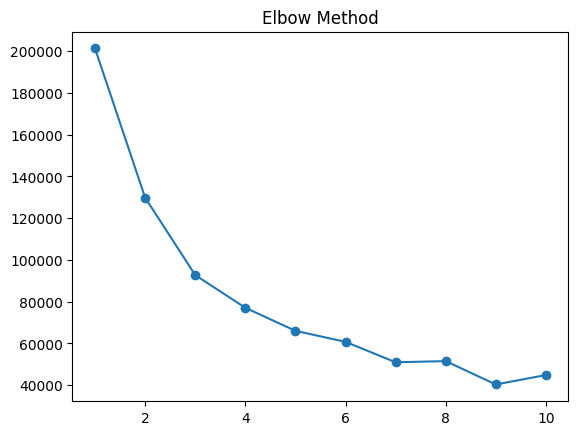

In [5]:

from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.show()


model = KMeans(n_clusters=3, init='k-means++', random_state=42)
rfm['Cluster'] = model.fit_predict(rfm_scaled)

# **Model Evaluation**

Silhouette Score: 0.36
            Recency  Frequency      Monetary
Cluster                                     
0        556.930550   1.527521   3931.573584
1        305.553661  11.454449  67862.026859
2        220.893289   1.537835   6932.905262


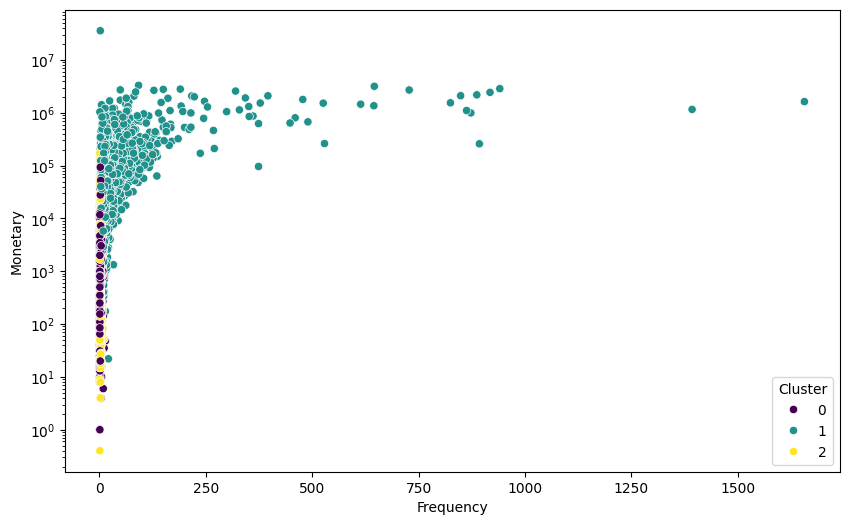

In [6]:

from sklearn.metrics import silhouette_score
print(f"Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.2f}")


cluster_results = rfm.groupby('Cluster').mean()
print(cluster_results)

plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='viridis')
plt.yscale('log')
plt.show()